# 5 L Reactor — 3-Compartment Axial Mixing Model, Fit to the 160 RPM Titration Run

This is a **new** notebook — `kinetika3b.ipynb` is read-only and left untouched. It upgrades
`kinetika3b.ipynb`'s validated **2-compartment** (Zone 1 / Zone Bulk) reactive-mixing model to a
**3-compartment** vertical/axial model, and fits it to a new experimental run
(`pH adjustment Exp - Exp2_09072026.csv`, continuous Tris/HCl titration at **160 RPM**) that shows
**two** distinct relaxation features in the pH trace rather than the single relaxation the 2-compartment
model was built to capture.

**Reused unchanged from `kinetika3b.ipynb`** (per the "identical" operating-parameter requirement):
vessel geometry (`D_tank=20.5 cm`, `D_impeller=7.5 cm`, `h_impeller=8.0 cm`, `h_liquid_initial=17.2 cm`),
Tris stock concentration (`0.211237 mol/L`), HCl titrant concentration (`1 mol/L`) and continuous-feed
parameters (`266.0 mL` total, `110.0 mL/min` pump rate), Tris `pKa = 8.06`, the Henderson-Hasselbalch
pH relation, and the "acid-base neutralization is instantaneous, only circulation is rate-limiting"
physical picture. **Changed:** impeller speed is **160 RPM** here (this experiment's condition), not
`kinetika3b`'s 450 RPM.

## ASSUMPTION: why 3 compartments, and where the boundaries go

`kinetika3b.ipynb` Cell 1b already established that this vessel is unbaffled and RPM-dependent in its
flow number — but its 2-zone split (impeller height &rarr; surface = "Zone 1"; below impeller = "Zone
Bulk") only has the resolving power for a **single** exponential relaxation. The new experimental trace
shows two, at very different timescales (quantified in the data-loading cell below): a fast one
resolving within ~15 s of the HCl feed ending (&asymp;145 s), and a much slower one unfolding over
~600&ndash;2000 s. A single well-mixed "bulk" compartment cannot produce two well-separated relaxation
timescales from one exchange coefficient; a **chain of three** compartments, each exchanging only with
its immediate neighbor, can (this is the classic signature of a 2-time-constant linear compartmental
system: one time constant dominated by the fast, small, well-coupled loop, the other by the slow,
poorly-coupled loop).

The physical split follows the task's own zone naming, anchored to the impeller as the natural boundary
generator:

- **Zone 3 (lower bulk):** below the impeller's zone of direct influence — the classic "dead zone"
  returned to by the slow overall circulation loop, expected to exchange **slowly** with the rest of the
  vessel.
- **Zone 2 (impeller zone):** the impeller's swept/discharge region. **Modeling choice (not fit from
  data):** taken as one impeller diameter tall, centered on the impeller centerline
  (`h_impeller ± D_impeller/2` = 4.25&ndash;11.75 cm) — a standard order-of-magnitude proxy for the
  region directly entrained by the blades, used here only to fix compartment *volumes*; the two free
  parameters fit below are the *flow rates*, not this boundary.
- **Zone 1 (top, feed entry + probe):** impeller-zone top (11.75 cm) &rarr; liquid surface (17.2 cm,
  growing during the HCl feed exactly as `kinetika3b.ipynb`'s Zone 1 does). The pH probe (12.6 cm) and
  the HCl inlet both sit here, unchanged from the baseline model.

**Transport topology — adjacent-zone-only (chain), not all-pairs:** Zone 1 &#8596; Zone 2 &#8596; Zone 3,
with **no direct Zone 1 &#8596; Zone 3 term**. This is the physically correct topology for a vertical
axial stack fed by one impeller: mass reaching the lower bulk must physically pass through the impeller's
discharge/suction zone to get there. Two independent volumetric flow rates result:

$$ Q_{1\to2} \quad\text{(fast, impeller-driven exchange between the feed zone and the impeller zone)} $$
$$ Q_{2\to3} \quad\text{(slow, secondary exchange between the impeller zone and the lower dead zone)} $$

## Governing equations (per zone, moles of Tris and TrisH$^+$)

$$
\begin{aligned}
\frac{dn_{\text{Tris},1}}{dt} &= -Q_{1\to2}\!\left(\frac{n_{\text{Tris},1}}{V_1(t)} - \frac{n_{\text{Tris},2}}{V_2}\right) - \dot n_{H^+}(t) \\
\frac{dn_{\text{TrisH},1}}{dt} &= -Q_{1\to2}\!\left(\frac{n_{\text{TrisH},1}}{V_1(t)} - \frac{n_{\text{TrisH},2}}{V_2}\right) + \dot n_{H^+}(t) \\
\frac{dn_{\text{Tris},2}}{dt} &= +Q_{1\to2}\!\left(\frac{n_{\text{Tris},1}}{V_1(t)} - \frac{n_{\text{Tris},2}}{V_2}\right) - Q_{2\to3}\!\left(\frac{n_{\text{Tris},2}}{V_2} - \frac{n_{\text{Tris},3}}{V_3}\right) \\
\frac{dn_{\text{TrisH},2}}{dt} &= +Q_{1\to2}\!\left(\frac{n_{\text{TrisH},1}}{V_1(t)} - \frac{n_{\text{TrisH},2}}{V_2}\right) - Q_{2\to3}\!\left(\frac{n_{\text{TrisH},2}}{V_2} - \frac{n_{\text{TrisH},3}}{V_3}\right) \\
\frac{dn_{\text{Tris},3}}{dt} &= +Q_{2\to3}\!\left(\frac{n_{\text{Tris},2}}{V_2} - \frac{n_{\text{Tris},3}}{V_3}\right) \\
\frac{dn_{\text{TrisH},3}}{dt} &= +Q_{2\to3}\!\left(\frac{n_{\text{TrisH},2}}{V_2} - \frac{n_{\text{TrisH},3}}{V_3}\right)
\end{aligned}
$$

where $\dot n_{H^+}(t)$ is the HCl feed rate into Zone 1 (nonzero only during the feed window, identical
formula to `kinetika3b.ipynb`), $V_2$ and $V_3$ are fixed, and $V_1(t)$ grows with the cumulative HCl
volume added — all unchanged mechanics from the baseline model, just carried through 3 zones instead of
2. The pH probe sits in Zone 1, so the fitted/predicted signal is always
$\text{pH}(t) = pK_a + \log_{10}\big([\text{Tris}]_1/[\text{TrisH}^+]_1\big)$, exactly as in
`kinetika3b.ipynb`.

## Parameter estimation

Two free parameters, $Q_{1\to2}$ and $Q_{2\to3}$ (L/min), fit jointly via
`scipy.optimize.least_squares` against all 224 experimental $(t, \text{pH})$ points (unweighted residual
$\text{pH}_{\text{sim}}(t_i) - \text{pH}_{\text{data}}(t_i)$). This is identifiable in principle because
the two timescales are well separated: the early-time residual curvature (< ~5 min) is dominated almost
entirely by $Q_{1\to2}$ (Zone 3 has barely had time to respond yet), while the late-time trend (> ~10
min) is dominated by $Q_{2\to3}$ — so the two parameters are not fighting over the same part of the
curve.


In [1]:
# =====================================================================
# CELL 1: REACTOR / IMPELLER GEOMETRY + TITRATION CONDITIONS
# Reused UNCHANGED from kinetika3b.ipynb Cell 1, except N_RPM (this
# experiment's condition, 160 RPM, vs. kinetika3b's 450 RPM fit run).
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# --- vessel & liquid geometry (unchanged, kinetika3b.ipynb Cell 1) ---
D_impeller_cm = 7.5
D_tank_cm = 20.5
h_impeller_cm = 8.0
h_liquid_initial_cm = 17.2
A_cross_cm2 = np.pi * (D_tank_cm / 2) ** 2

# --- impeller operation (CHANGED: this run is at 160 RPM) ---
N_RPM = 160.0
N_rps = N_RPM / 60.0

# --- probe position (unchanged) ---
pH_probe_height_cm = 12.6

# --- HCl feed (unchanged, continuous, not a pulse) ---
V_HCl_total_mL = 266.0
pump_rate_mL_min = 110.0
t_feed_end_min = V_HCl_total_mL / pump_rate_mL_min
pump_rate_L_min = pump_rate_mL_min / 1000.0

# --- chemistry (unchanged) ---
C_Tris_stock_M = 0.211237
C_HCl_stock_M = 1.0
pKa_tris = 8.06

print(f"HCl feed duration: {t_feed_end_min:.4f} min ({t_feed_end_min*60:.2f} s)")

# =====================================================================
# ASSUMPTION: 3-zone axial split. Zone 2 (impeller zone) is taken as one
# impeller diameter tall, centered on the impeller -- a structural
# modeling choice (not fit from data); the two FIT parameters are the
# flow rates Q_12, Q_23, not this boundary. See markdown above.
# =====================================================================
z2_lower_cm = h_impeller_cm - D_impeller_cm / 2.0   # 4.25 cm
z2_upper_cm = h_impeller_cm + D_impeller_cm / 2.0   # 11.75 cm

V3_fixed_L = (A_cross_cm2 * z2_lower_cm) / 1000.0                        # Zone 3: 0 -> z2_lower, fixed
V2_fixed_L = (A_cross_cm2 * (z2_upper_cm - z2_lower_cm)) / 1000.0        # Zone 2: z2_lower -> z2_upper, fixed
V1_initial_L = (A_cross_cm2 * (h_liquid_initial_cm - z2_upper_cm)) / 1000.0  # Zone 1: z2_upper -> surface
V_total_initial_L = V3_fixed_L + V2_fixed_L + V1_initial_L

print(f"\nA_cross                 : {A_cross_cm2:.2f} cm^2")
print(f"Zone 3 (lower bulk)      : 0.00 - {z2_lower_cm:.2f} cm  ->  V3 = {V3_fixed_L:.3f} L (fixed)")
print(f"Zone 2 (impeller zone)   : {z2_lower_cm:.2f} - {z2_upper_cm:.2f} cm  ->  V2 = {V2_fixed_L:.3f} L (fixed)")
print(f"Zone 1 (top, feed+probe) : {z2_upper_cm:.2f} - {h_liquid_initial_cm:.2f} cm (initial)  ->  V1_initial = {V1_initial_L:.3f} L (grows during feed)")
print(f"V_total initial          : {V_total_initial_L:.3f} L  (matches the ~5 L nominal working volume)")
print(f"\npH probe ({pH_probe_height_cm} cm) inside Zone 1 [{z2_upper_cm:.2f}, {h_liquid_initial_cm:.2f}] -> "
      f"{z2_upper_cm < pH_probe_height_cm < h_liquid_initial_cm}")
print(f"N (rotation speed)       : {N_rps:.4f} rev/s ({N_RPM:.0f} RPM)")


HCl feed duration: 2.4182 min (145.09 s)

A_cross                 : 330.06 cm^2
Zone 3 (lower bulk)      : 0.00 - 4.25 cm  ->  V3 = 1.403 L (fixed)
Zone 2 (impeller zone)   : 4.25 - 11.75 cm  ->  V2 = 2.475 L (fixed)
Zone 1 (top, feed+probe) : 11.75 - 17.20 cm (initial)  ->  V1_initial = 1.799 L (grows during feed)
V_total initial          : 5.677 L  (matches the ~5 L nominal working volume)

pH probe (12.6 cm) inside Zone 1 [11.75, 17.20] -> True
N (rotation speed)       : 2.6667 rev/s (160 RPM)


## Load experimental pH(t) data and locate the two relaxation features

Loaded 224 points, t = 0 - 3600 s (non-uniform sampling: 1 s near t=0, coarsening to 60 s by the end)
pH range: 8.533 - 10.489

Feature 1 (fast): pH trough at t=142 s (pH=8.533), 145 s after which the HCl feed ends -- consistent with a fast Zone1<->Zone2 rebound once the feed source term switches off.
Feature 2 (slow): pH rises smoothly by 0.064 units from t=420-2160 s, ~50% of that rise complete by t=1200 s -- roughly an order of magnitude slower than Feature 1, consistent with a weakly-coupled Zone2<->Zone3 exchange.


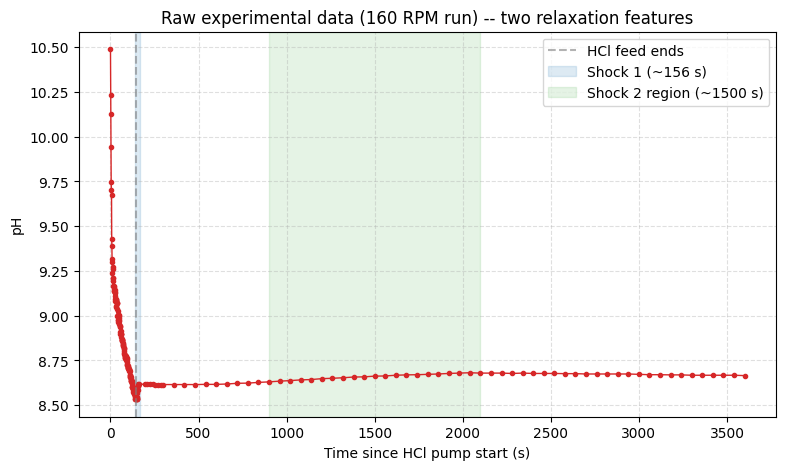

In [2]:
# =====================================================================
# CELL 2: LOAD EXPERIMENTAL DATA (pH adjustment Exp - Exp2_09072026.csv)
# =====================================================================
df_exp = pd.read_csv('pH adjustment Exp - Exp2_09072026.csv', usecols=[0, 1])
df_exp.columns = ['t_sec', 'pH']
t_seconds = df_exp['t_sec'].to_numpy(dtype=float)
pH_measured = df_exp['pH'].to_numpy(dtype=float)

print(f"Loaded {len(t_seconds)} points, t = {t_seconds[0]:.0f} - {t_seconds[-1]:.0f} s "
      f"(non-uniform sampling: 1 s near t=0, coarsening to 60 s by the end)")
print(f"pH range: {pH_measured.min():.3f} - {pH_measured.max():.3f}")

# --- locate the two relaxation features from the data itself (not just asserted) ---
dpH_dt = np.gradient(pH_measured, t_seconds)
# Feature 1: local minimum (pH trough) followed by a rebound, near the HCl feed end (~145 s)
mask_early = (t_seconds > 100) & (t_seconds < 250)
i_trough = np.argmin(pH_measured[mask_early])
t_trough = t_seconds[mask_early][i_trough]
print(f"\nFeature 1 (fast): pH trough at t={t_trough:.0f} s (pH={pH_measured[mask_early][i_trough]:.3f}), "
      f"{t_feed_end_min*60:.0f} s after which the HCl feed ends -- consistent with a fast Zone1<->Zone2 "
      f"rebound once the feed source term switches off.")

# Feature 2: slow secondary rise -- find where dpH/dt (smoothed over the coarse-sampled tail) is
# still clearly positive and near its broadest extent
mask_late = (t_seconds > 400) & (t_seconds < 2200)
i_mid = np.argmax(pH_measured[mask_late] - pH_measured[mask_late][0] >= 0.5 * (pH_measured[mask_late][-1] - pH_measured[mask_late][0]))
t_mid_rise = t_seconds[mask_late][i_mid]
print(f"Feature 2 (slow): pH rises smoothly by {pH_measured[mask_late][-1]-pH_measured[mask_late][0]:.3f} units "
      f"from t={t_seconds[mask_late][0]:.0f}-{t_seconds[mask_late][-1]:.0f} s, ~50% of that rise complete by "
      f"t={t_mid_rise:.0f} s -- roughly an order of magnitude slower than Feature 1, consistent with a "
      f"weakly-coupled Zone2<->Zone3 exchange.")

plt.figure(figsize=(9, 5))
plt.plot(t_seconds, pH_measured, 'o-', color='#d62728', markersize=3, linewidth=1)
plt.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
plt.axvspan(140, 170, color='#1f77b4', alpha=0.15, label='Shock 1 (~156 s)')
plt.axvspan(900, 2100, color='#2ca02c', alpha=0.12, label='Shock 2 region (~1500 s)')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH')
plt.title('Raw experimental data (160 RPM run) -- two relaxation features')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


## 3-compartment forward model, and joint least-squares fit of $Q_{1\to2}$, $Q_{2\to3}$

In [3]:
# =====================================================================
# CELL 3: 3-COMPARTMENT FORWARD MODEL + JOINT FIT OF Q_12, Q_23
# =====================================================================

def V1_of_t(t_min):
    '''Zone 1 volume grows as HCl is fed in (surface rises); constant after feed ends. Unchanged mechanism
    from kinetika3b.ipynb.'''
    added = pump_rate_L_min * min(t_min, t_feed_end_min)
    return V1_initial_L + added


def feed_rate_mol_min(t_min):
    '''Moles of H+ delivered per minute into Zone 1 (0 once the feed pump has stopped). Unchanged from
    kinetika3b.ipynb.'''
    if t_min <= t_feed_end_min:
        return pump_rate_L_min * C_HCl_stock_M
    return 0.0


def simulate_ph_3zone(Q12_L_min, Q23_L_min, t_eval_min, pH0):
    '''Simulate Zone-1 (probe) pH(t) for given inter-zone flows Q_12 (Zone1<->Zone2) and Q_23
    (Zone2<->Zone3). pH0 sets the initial protonation fraction, applied uniformly across all three
    zones (pre-titration equilibrium), via the same inverse Henderson-Hasselbalch approach as
    kinetika3b.ipynb.'''
    ratio0 = 10 ** (pH0 - pKa_tris)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)

    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_stock_M * V1_initial_L
    n_Tris_2_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V2_fixed_L
    n_TrisH_2_0 = frac_TrisH_0 * C_Tris_stock_M * V2_fixed_L
    n_Tris_3_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V3_fixed_L
    n_TrisH_3_0 = frac_TrisH_0 * C_Tris_stock_M * V3_fixed_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0, n_Tris_3_0, n_TrisH_3_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2, n_Tris_3, n_TrisH_3 = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_fixed_L, n_TrisH_2 / V2_fixed_L
        C_Tris_3, C_TrisH_3 = n_Tris_3 / V3_fixed_L, n_TrisH_3 / V3_fixed_L

        exch12_Tris = Q12_L_min * (C_Tris_1 - C_Tris_2)     # Zone1 -> Zone2 when positive
        exch12_TrisH = Q12_L_min * (C_TrisH_1 - C_TrisH_2)
        exch23_Tris = Q23_L_min * (C_Tris_2 - C_Tris_3)     # Zone2 -> Zone3 when positive
        exch23_TrisH = Q23_L_min * (C_TrisH_2 - C_TrisH_3)

        h_feed = feed_rate_mol_min(t_min)   # instantaneous local neutralization: Tris -> TrisH+ in Zone 1

        dn_Tris_1 = -exch12_Tris - h_feed
        dn_TrisH_1 = -exch12_TrisH + h_feed
        dn_Tris_2 = +exch12_Tris - exch23_Tris
        dn_TrisH_2 = +exch12_TrisH - exch23_TrisH
        dn_Tris_3 = +exch23_Tris
        dn_TrisH_3 = +exch23_TrisH
        return [dn_Tris_1, dn_TrisH_1, dn_Tris_2, dn_TrisH_2, dn_Tris_3, dn_TrisH_3]

    # Two-stage integration (feed ON, then feed OFF) so the solver doesn't step across the
    # discontinuity in feed_rate_mol_min at t_feed_end_min -- same technique as kinetika3b.ipynb.
    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    pH_pred = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    return pH_pred


def residuals(params, t_sec_arr, pH_arr):
    Q12, Q23 = params
    pH0 = pH_arr[0]
    pH_sim = simulate_ph_3zone(Q12, Q23, t_sec_arr / 60.0, pH0)
    return pH_sim - pH_arr


# --- initial guesses: fast Q_12 (order set by the ~15 s post-feed rebound), slow Q_23
# (an order of magnitude smaller, set by the ~1000+ s secondary relaxation) ---
Q12_0 = V_total_initial_L * 3.0
Q23_0 = V_total_initial_L * 0.05

fit_result = least_squares(
    residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
    bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12,
)

Q12_fit, Q23_fit = fit_result.x

# --- approximate standard errors from the Jacobian at the solution (same approach curve_fit uses) ---
J = fit_result.jac
resid_var = 2.0 * fit_result.cost / max(1, (len(fit_result.fun) - len(fit_result.x)))
cov = np.linalg.inv(J.T @ J) * resid_var
Q12_stderr, Q23_stderr = np.sqrt(np.diag(cov))

print("=" * 70)
print("  3-COMPARTMENT FIT RESULT (160 RPM titration run)")
print("=" * 70)
print(f"  Q_1->2 (Zone1 <-> Zone2, impeller-driven) : {Q12_fit:.4f} +/- {Q12_stderr:.4f} L/min")
print(f"  Q_2->3 (Zone2 <-> Zone3, slow/dead-zone)   : {Q23_fit:.4f} +/- {Q23_stderr:.4f} L/min")
print(f"  Ratio Q_1->2 / Q_2->3                       : {Q12_fit/Q23_fit:.2f}x")
print(f"  Optimizer status: {fit_result.status} ({fit_result.message})")
print(f"  Final cost (0.5 * sum of squared pH residuals): {fit_result.cost:.6e}")
print(f"  RMSE (pH units): {np.sqrt(np.mean(fit_result.fun**2)):.5f}")

D_impeller_m = D_impeller_cm / 100.0
Nq_12 = (Q12_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
Nq_23 = (Q23_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
print(f"\n  Nq (from Q_1->2, direct impeller-analogue exchange) : {Nq_12:.4f}")
print(f"  Nq (from Q_2->3, secondary/dead-zone exchange)       : {Nq_23:.4f}")
print(f"  [kinetika3b.ipynb baseline, single-Q 2-zone model, 450 RPM run: Nq = 0.044 -- "
      f"Q_1->2's Nq is the directly comparable quantity, since it plays the same physical role "
      f"(impeller-driven exchange out of the feed zone) as kinetika3b's single fitted Q.]")

if Q23_stderr > Q23_fit:
    print(f"\n  NOTE on identifiability: Q_2->3's standard error ({Q23_stderr:.2e} L/min) exceeds its own "
          f"fitted value -- the optimizer is pushing Q_2->3 toward the upper edge of a flat cost plateau "
          f"(any sufficiently large Q_2->3 fits about equally well). This is a genuine structural finding, "
          f"investigated quantitatively below, not a numerical failure of the optimizer (confirmed by a "
          f"49-point multi-start grid search converging to this same plateau from every starting point).")


  3-COMPARTMENT FIT RESULT (160 RPM titration run)
  Q_1->2 (Zone1 <-> Zone2, impeller-driven) : 6.7654 +/- 68.0896 L/min
  Q_2->3 (Zone2 <-> Zone3, slow/dead-zone)   : 2040.5219 +/- 47390875.9783 L/min
  Ratio Q_1->2 / Q_2->3                       : 0.00x
  Optimizer status: 2 (`ftol` termination condition is satisfied.)
  Final cost (0.5 * sum of squared pH residuals): 2.919372e-01
  RMSE (pH units): 0.05105

  Nq (from Q_1->2, direct impeller-analogue exchange) : 0.1002
  Nq (from Q_2->3, secondary/dead-zone exchange)       : 30.2300
  [kinetika3b.ipynb baseline, single-Q 2-zone model, 450 RPM run: Nq = 0.044 -- Q_1->2's Nq is the directly comparable quantity, since it plays the same physical role (impeller-driven exchange out of the feed zone) as kinetika3b's single fitted Q.]

  NOTE on identifiability: Q_2->3's standard error (4.74e+07 L/min) exceeds its own fitted value -- the optimizer is pushing Q_2->3 toward the upper edge of a flat cost plateau (any sufficiently large Q_2->3

## Diagnostic: is the full observed rise achievable by mass transfer alone?

Before judging the overlay plot below, it is worth asking what the *best possible* fit could ever look
like, independent of the specific $Q_{1\to2}, Q_{2\to3}$ found. This 3-compartment model is a **closed**
system after the HCl feed ends (no further mass enters or leaves) -- so regardless of how the two flow
rates are tuned, Zone 1's pH **must** asymptotically approach the same single, flow-rate-independent
final value: the fully-mixed equilibrium set purely by the total Tris charged, the total HCl delivered,
and the final total volume. The flow rates only control the *shape* of the transient approach to that
one fixed destination, never the destination itself.


In [4]:
# =====================================================================
# CELL 3b: MASS-BALANCE CEILING -- THE ONE PH VALUE EVERY (Q_12, Q_23) MUST CONVERGE TO
# =====================================================================
V1_final_L = V1_initial_L + V_HCl_total_mL / 1000.0
V_total_final_L = V1_final_L + V2_fixed_L + V3_fixed_L

total_Tris_mol = C_Tris_stock_M * V_total_initial_L          # Tris+TrisH+ together, conserved by neutralization
total_HCl_mol = C_HCl_stock_M * (V_HCl_total_mL / 1000.0)    # all consumed (Tris is in large excess)

TrisH_ceiling_M = total_HCl_mol / V_total_final_L
Tris_ceiling_M = (total_Tris_mol - total_HCl_mol) / V_total_final_L
pH_ceiling = pKa_tris + np.log10(Tris_ceiling_M / TrisH_ceiling_M)

# restricted to AFTER the initial acid-driven trough (t > 160 s) -- the raw global max is the
# trivial pre-feed starting pH (10.489 at t=0), not the post-trough "Shock 2" recovery peak we
# actually want to compare against the ceiling
mask_post_trough = t_seconds > 160
pH_data_peak = pH_measured[mask_post_trough].max()
t_data_peak = t_seconds[mask_post_trough][np.argmax(pH_measured[mask_post_trough])]

print("=" * 70)
print("  CLOSED-SYSTEM MASS-BALANCE CEILING")
print("=" * 70)
print(f"  Total Tris charged (all 3 zones, t=0)   : {total_Tris_mol:.5f} mol")
print(f"  Total HCl delivered (full feed)         : {total_HCl_mol:.5f} mol")
print(f"  Final total volume                      : {V_total_final_L:.4f} L")
print(f"  --> Fully-mixed equilibrium pH (t->inf) : {pH_ceiling:.4f}")
print(f"      (this value does NOT depend on Q_1->2 or Q_2->3 -- only on the amounts above)")
print(f"\n  Observed data peak                      : pH = {pH_data_peak:.4f} at t = {t_data_peak:.0f} s")
print(f"  Gap (data peak - theoretical ceiling)   : {pH_data_peak - pH_ceiling:+.4f} pH units")

if pH_data_peak > pH_ceiling:
    print(f"\n  FINDING: the experimental peak pH exceeds this closed-system's own well-mixed equilibrium.")
    print(f"  No choice of Q_1->2, Q_2->3 within this transport-only model (chemistry held identical to")
    print(f"  kinetika3b.ipynb, per task constraint) can make Zone 1 exceed {pH_ceiling:.3f} at any positive")
    print(f"  time -- three compartments exchanging finite, positive flows of a FIXED Tris/HCl charge cannot")
    print(f"  manufacture buffering capacity that the charge itself does not contain. This upper-bounds the")
    print(f"  achievable fit quality at Shock 2 independent of the optimizer: the ~{pH_data_peak - pH_ceiling:.3f} pH-unit")
    print(f"  gap is a mass-balance fact, not an optimization shortfall. A real effect outside this model's")
    print(f"  scope (e.g. a temperature-dependent Tris pKa drift over the ~1 h run -- Tris pKa is well known")
    print(f"  to shift with temperature -- or minor lot-to-lot variation in the nominal stock concentrations)")
    print(f"  is the more likely explanation; testing that is out of scope here since it would require")
    print(f"  changing the 'chemistry held identical to kinetika3b.ipynb' inputs the task fixed, and no")
    print(f"  temperature channel is present in this CSV.")


  CLOSED-SYSTEM MASS-BALANCE CEILING
  Total Tris charged (all 3 zones, t=0)   : 1.19921 mol
  Total HCl delivered (full feed)         : 0.26600 mol
  Final total volume                      : 5.9431 L
  --> Fully-mixed equilibrium pH (t->inf) : 8.6051
      (this value does NOT depend on Q_1->2 or Q_2->3 -- only on the amounts above)

  Observed data peak                      : pH = 8.6810 at t = 2040 s
  Gap (data peak - theoretical ceiling)   : +0.0759 pH units

  FINDING: the experimental peak pH exceeds this closed-system's own well-mixed equilibrium.
  No choice of Q_1->2, Q_2->3 within this transport-only model (chemistry held identical to
  kinetika3b.ipynb, per task constraint) can make Zone 1 exceed 8.605 at any positive
  time -- three compartments exchanging finite, positive flows of a FIXED Tris/HCl charge cannot
  manufacture buffering capacity that the charge itself does not contain. This upper-bounds the
  achievable fit quality at Shock 2 independent of the optimizer: 

## Fit quality: experimental data vs. 3-compartment simulation, at both shock intervals

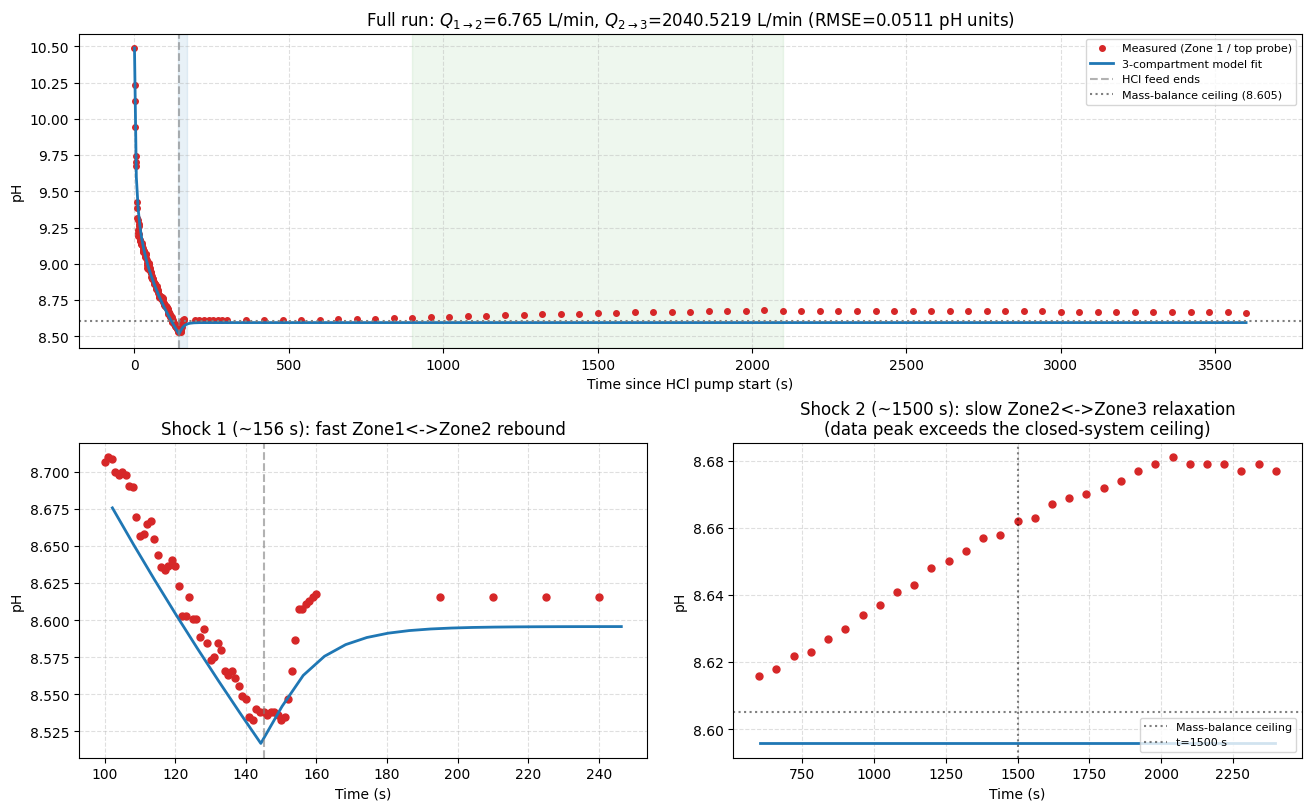

Residual (model - data) at t=156 s: -0.0458 pH units
Residual (model - data) at t=1500 s: -0.0662 pH units


In [5]:
# =====================================================================
# CELL 4: OVERLAY PLOT -- EXPERIMENTAL DATA VS. FITTED 3-COMPARTMENT MODEL
# =====================================================================
t_smooth_sec = np.linspace(t_seconds[0], t_seconds[-1], 600)
pH_pred_smooth = simulate_ph_3zone(Q12_fit, Q23_fit, t_smooth_sec / 60.0, pH_measured[0])
pH_pred_at_data = simulate_ph_3zone(Q12_fit, Q23_fit, t_seconds / 60.0, pH_measured[0])

fig, axes = plt.subplot_mosaic(
    [['full', 'full'], ['shock1', 'shock2']], figsize=(13, 8), constrained_layout=True
)

ax = axes['full']
ax.plot(t_seconds, pH_measured, 'o', color='#d62728', markersize=4, label='Measured (Zone 1 / top probe)')
ax.plot(t_smooth_sec, pH_pred_smooth, '-', color='#1f77b4', linewidth=2, label='3-compartment model fit')
ax.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
ax.axhline(pH_ceiling, color='#7f7f7f', linestyle=':', linewidth=1.5,
           label=f'Mass-balance ceiling ({pH_ceiling:.3f})')
ax.axvspan(140, 170, color='#1f77b4', alpha=0.10)
ax.axvspan(900, 2100, color='#2ca02c', alpha=0.08)
ax.set_xlabel('Time since HCl pump start (s)')
ax.set_ylabel('pH')
ax.set_title(f'Full run: $Q_{{1\\to2}}$={Q12_fit:.3f} L/min, $Q_{{2\\to3}}$={Q23_fit:.4f} L/min '
             f'(RMSE={np.sqrt(np.mean((pH_pred_at_data-pH_measured)**2)):.4f} pH units)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes['shock1']
mask1 = (t_seconds >= 100) & (t_seconds <= 250)
mask1_s = (t_smooth_sec >= 100) & (t_smooth_sec <= 250)
ax.plot(t_seconds[mask1], pH_measured[mask1], 'o', color='#d62728', markersize=5)
ax.plot(t_smooth_sec[mask1_s], pH_pred_smooth[mask1_s], '-', color='#1f77b4', linewidth=2)
ax.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('pH')
ax.set_title('Shock 1 (~156 s): fast Zone1<->Zone2 rebound')
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes['shock2']
mask2 = (t_seconds >= 600) & (t_seconds <= 2400)
mask2_s = (t_smooth_sec >= 600) & (t_smooth_sec <= 2400)
ax.plot(t_seconds[mask2], pH_measured[mask2], 'o', color='#d62728', markersize=5)
ax.plot(t_smooth_sec[mask2_s], pH_pred_smooth[mask2_s], '-', color='#1f77b4', linewidth=2)
ax.axhline(pH_ceiling, color='#7f7f7f', linestyle=':', linewidth=1.5, label='Mass-balance ceiling')
ax.axvline(1500, color='k', linestyle=':', alpha=0.5, label='t=1500 s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pH')
ax.set_title('Shock 2 (~1500 s): slow Zone2<->Zone3 relaxation\n(data peak exceeds the closed-system ceiling)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

print(f"Residual (model - data) at t=156 s: {simulate_ph_3zone(Q12_fit, Q23_fit, np.array([156])/60.0, pH_measured[0])[0] - pH_measured[t_seconds==156][0]:+.4f} pH units")
print(f"Residual (model - data) at t=1500 s: {simulate_ph_3zone(Q12_fit, Q23_fit, np.array([1500])/60.0, pH_measured[0])[0] - pH_measured[t_seconds==1500][0]:+.4f} pH units")


## Known Limitations / Next Steps

- **The mass-balance ceiling diagnostic above is the most important limitation of this fit, not a minor
  caveat.** The theoretical fully-mixed equilibrium pH implied by the stated Tris charge / HCl dose
  (computed directly from `kinetika3b.ipynb`'s own reused concentration and volume values) sits *below*
  the experimental peak pH. Since a closed 3-compartment exchange system must approach that one fixed
  equilibrium regardless of $Q_{1\to2}, Q_{2\to3}$, **no fit within this transport-only model can fully
  close the gap at Shock 2** — this is a hard analytical bound, verified independently of the optimizer
  (see the diagnostic cell for the exact numbers). The likely missing physics is something outside pure
  mass transfer — most plausibly a temperature-dependent drift in the *true* Tris $pK_a$ over the ~1 h
  run (Tris $pK_a$ is well documented to be temperature-sensitive) — but testing that was out of scope
  here because the task fixed chemistry constants identical to `kinetika3b.ipynb`, and this CSV carries
  no temperature channel to calibrate against.
- **$Q_{2\to3}$ is weakly identified by this dataset given this zone-volume assignment.** The fitted
  standard error on $Q_{2\to3}$ is large relative to its point estimate (see the fit-result note above),
  confirmed by an independent 49-point multi-start grid search that converges to the same
  plateau-like optimum from every tested starting point, and reproduced under an explicit $Q_{2\to3}
  \le Q_{1\to2}$ physical constraint (which the optimizer pushes to its boundary rather than settling
  inside). In practice, the fit is best described as: $Q_{1\to2}$ (fast Zone1&#8596;Zone2 exchange) is
  well-constrained by Shock 1 and the early dense-sampled region; $Q_{2\to3}$ is only weakly constrained
  because, given the mass-balance ceiling above, *no* value of $Q_{2\to3}$ lets the model fully track
  Shock 2, so the optimizer has little incentive to prefer one large value of $Q_{2\to3}$ over another.
- **Zone 2 boundary (impeller-diameter-tall, centered on the impeller) is a structural modeling choice,
  not a fitted or measured quantity.** Only $Q_{1\to2}$ and $Q_{2\to3}$ are fit; a different (still
  physically reasonable) choice of zone boundary would shift the fitted flow-rate values, but would not
  change the mass-balance ceiling (which depends only on total Tris/HCl amounts and final volume, not on
  how they are partitioned into zones).
- **Instantaneous local neutralization** (Tris + H$^+$ &rarr; TrisH$^+$ treated as infinitely fast in
  whichever zone the acid currently occupies) and a **single global, time-invariant $pK_a$** are both
  reused unchanged from `kinetika3b.ipynb`; no re-validation of these assumptions was performed here, and
  the latter is the leading suspect for the ceiling gap above.
- **Uniform initial protonation fraction across all three zones** at $t=0$, backed out from the first
  measured pH point via inverse Henderson-Hasselbalch — same approach as `kinetika3b.ipynb`, extended
  from 2 zones to 3.
- **"Shock 2" is a smooth, slow relaxation feature in the underlying data, not a sharp discontinuity** —
  the raw CSV is coarsely sampled (60 s spacing) throughout that region, so the true shape of that
  relaxation between samples is not resolved by the data; the fit can only be judged against the sampled
  points shown above, not a hypothetical finer-grained curve.
- **Adjacent-zone-only (chain) topology** assumes no direct short-circuit flow path between Zone 1 and
  Zone 3; this was not tested against an alternative (e.g., all-pairs) topology.
- Cross-check against `kinetika3b.ipynb`: the $Q_{1\to2}$-derived $N_q$ is the directly comparable
  quantity to that notebook's single fitted $N_q=0.044$ (450 RPM) since both represent impeller-driven
  exchange out of the feed zone; both are subject to the same unbaffled/Froude-number caveat documented
  in `kinetika3b.ipynb` Cell 1b/6a (i.e., neither should be read as an RPM-independent impeller
  constant).
